# ECON 3916: ML Prediction Project — Final Project

**From Question to Recommendation**

This notebook scaffolds your final project. Work through each part sequentially. By Week 12, this notebook (plus your `app.py` and report) will form your complete submission.

**AI Policy:** AI co-pilot is REQUIRED. Document every AI interaction in Part 7 (AI Methodology Appendix) using the P.R.I.M.E. framework.

---

## Part 0: Setup

In [2]:
# ============================================================
# Part 0: Setup — Run this cell first
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    mean_squared_error, mean_absolute_error, r2_score
)


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Setup complete.')

Setup complete.


---
## Part 1: Problem Statement

Fill in each blank below. This becomes the opening paragraph of your report.

**My prediction question is:** Can health, demographic, and behavioral indicators predict whether an individual has diabetes?

**This is a prediction (umbrella) problem because:**
(Reminder: prediction asks "can we forecast Y from X?" — not "does X cause Y?")

This is a prediction problem because the goal is to observe different variables to predict whether someone may have diabetes from X, rather then estimate whether X causes diabetes.

**The decision this enables:**
(Who is the stakeholder? What action would they take differently with your prediction?)

A public health screening program or clinic could use the model to identify people at higher predicted risk of diabetes and prioritize them for follow up appointments or early intervention.

**Dataset:** Diabetes Health Indicators Dataset
- **Source:**  (URL: https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset/data)
- **N =** 253,680 obersvations
- **Features =** 21 variables
- **Target variable =** Diabetes_binary
- **Access date:** April 18th, 2026

---
## Part 2: Data Loading + EDA

### 2.1 Load Your Data

In [3]:
import kagglehub


path = kagglehub.dataset_download("alexteboul/diabetes-health-indicators-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'diabetes-health-indicators-dataset' dataset.
Path to dataset files: /kaggle/input/diabetes-health-indicators-dataset


In [4]:
# ============================================================
# 2.1 Load your dataset
# ============================================================
# Replace the URL/path below with your data source

df = pd.read_csv('/kaggle/input/diabetes-health-indicators-dataset/diabetes_binary_health_indicators_BRFSS2015.csv')


print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (253680, 22)
Columns: ['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


### 2.2 Basic Description

In [5]:
# ============================================================
# 2.2 Describe your data
# ============================================================

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


### 2.3 Missing Data Assessment

Missing data (%) by column:
Series([], dtype: float64)


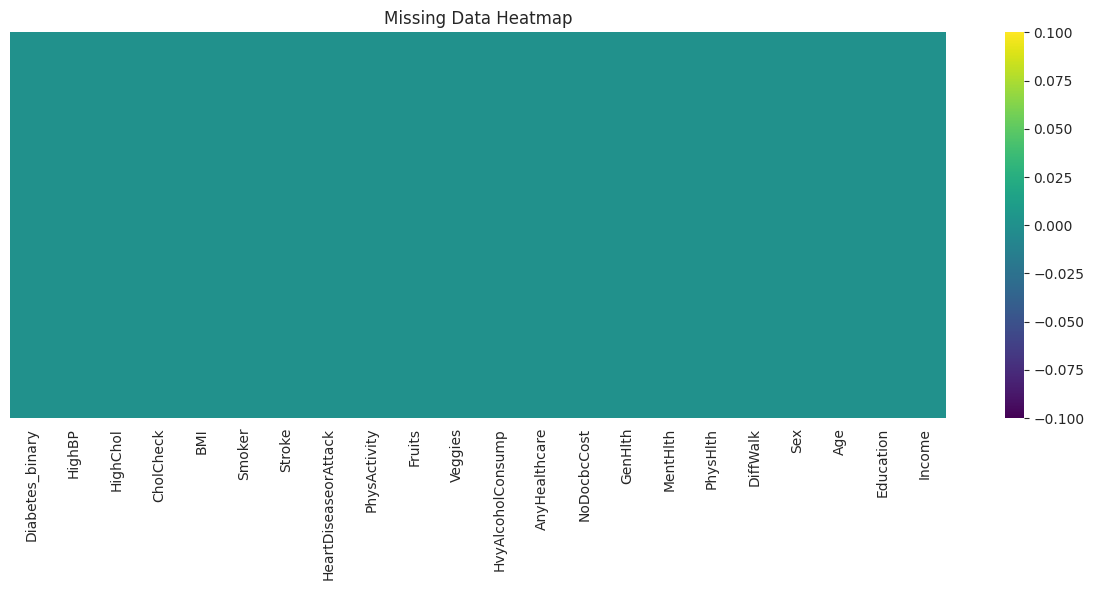

In [6]:
# ============================================================
# 2.3 Missing data heatmap (Ch 1: MCAR/MAR/MNAR)
# ============================================================

missing_pct = df.isnull().mean().sort_values(ascending=False)
print('Missing data (%) by column:')
print(missing_pct[missing_pct > 0])


plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.tight_layout()
plt.show()

**Missing data strategy:**
(Is this MCAR, MAR, or MNAR? What will you do — drop, impute, or flag?)
The CDC dataset has no missing values

### 2.4 Distribution Plots

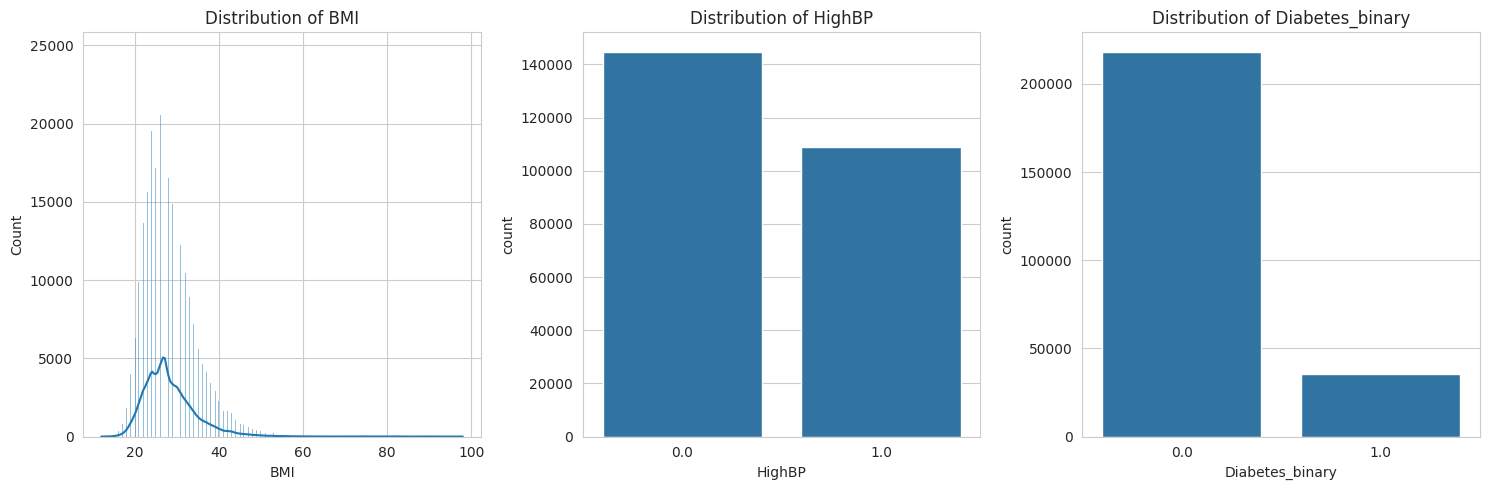

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 2.4 Distribution of key features (Ch 3)
# ============================================================


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(df['BMI'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of BMI')

sns.countplot(x=df['HighBP'], ax=axes[1])
axes[1].set_title('Distribution of HighBP')

sns.countplot(x=df['Diabetes_binary'], ax=axes[2])
axes[2].set_title('Distribution of Diabetes_binary')

plt.tight_layout()
plt.show()

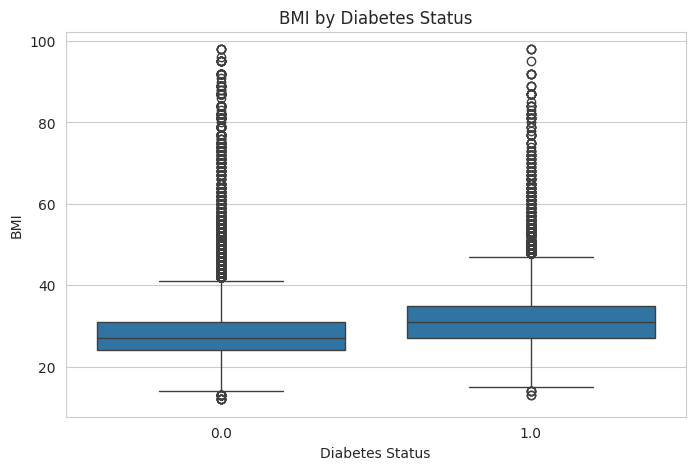

In [34]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Diabetes_binary', y='BMI', data=df)
plt.title('BMI by Diabetes Status')
plt.xlabel('Diabetes Status')
plt.ylabel('BMI')
plt.show()

Diabetes associated with slightly higher BMI's

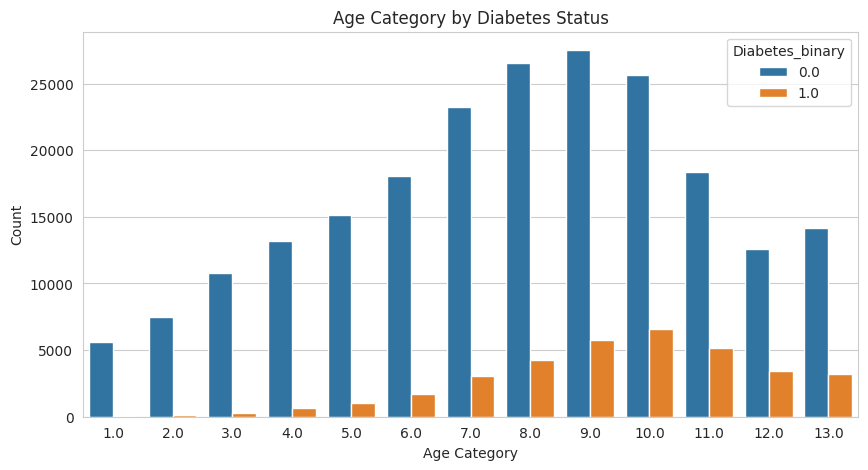

In [35]:
plt.figure(figsize=(10,5))
sns.countplot(x='Age', hue='Diabetes_binary', data=df)
plt.title('Age Category by Diabetes Status')
plt.xlabel('Age Category')
plt.ylabel('Count')
plt.show()

Diabetes cases appear more concentrated in older age categories.

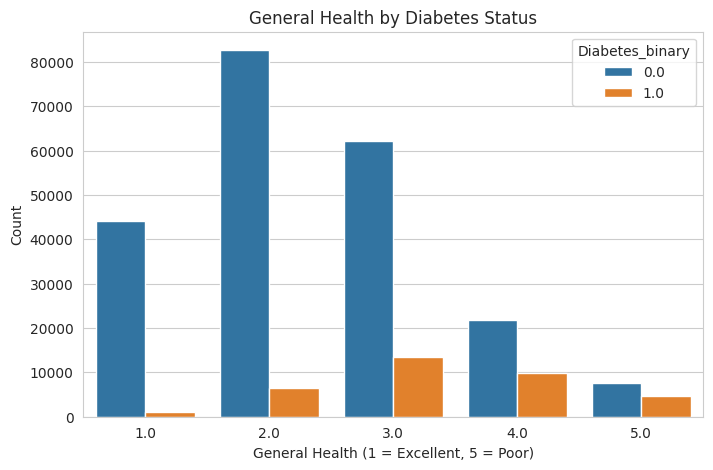

In [36]:
plt.figure(figsize=(8,5))
sns.countplot(x='GenHlth', hue='Diabetes_binary', data=df)
plt.title('General Health by Diabetes Status')
plt.xlabel('General Health (1 = Excellent, 5 = Poor)')
plt.ylabel('Count')
plt.show()

Individuals in the diabetes class are more concentrated in worse self-reported health categories.

### 2.5 Outlier Detection

In [8]:
# ============================================================
# 2.5 Outlier detection (Ch 4: Tukey Fences / IQR)
# ============================================================

def tukey_fences(series, k=1.5):
     """Return lower and upper Tukey fences."""
     Q1 = series.quantile(0.25)
     Q3 = series.quantile(0.75)
     IQR = Q3 - Q1
     return Q1 - k * IQR, Q3 + k * IQR

col = 'BMI'
lower, upper = tukey_fences(df[col])
outliers = df[(df[col] < lower) | (df[col] > upper)]
print(f'{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)')

BMI: 9847 outliers (3.9%)


**Outlier strategy:**
(Trim? Winsorize? Keep with justification?)
In this dataset potential outliers will be kept, as extreme values may indicate health risks.

### 2.6 Correlations

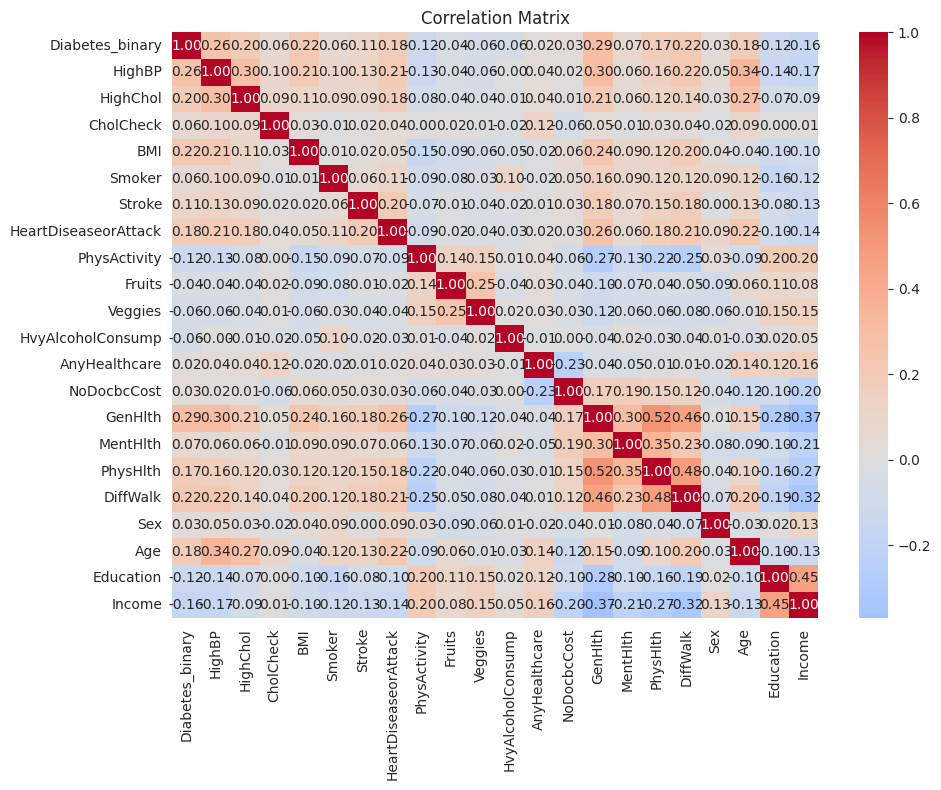

In [9]:
# ============================================================
# 2.6 Correlation heatmap (Ch 3)
# ============================================================

numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
#
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### YOUR TASK: Answer These 3 EDA Questions

1. **What is the distribution of your target variable?** Is it balanced (classification) or normally distributed (regression)? If not, what will you do about it?

   *Your answer:* The target variable, Diabetes_binary, is not balanced with many more non diabetes observations than diabetes observations. Due to this, looking at accuracy alone can be misleading. I will handle this by using proper metrics such as F1-score, ROC-AUC, and precision recall curves.

2. **Which features appear most correlated with the target?** Are any features highly correlated with each other (multicollinearity)?  

   *Your answer:* The features that appear to be most correlated with the targer are GenHlth, HighBP, BMI, HighChol, and PhysHlth. Some features that are highly correlated with eachother are Genhlth and PhysHlth, PhysHlth and and diffwalk, and education and income.

3. **What is the biggest data quality issue you found, and how will you handle it?**  

   *Your answer:* The biggest data quality issue is class imbalance. The dataset doesn't have any missing values, so the main issue is that the imbalance may bias evaluation.

### 2.7 Data Quality Summary

**Data Quality Summary**

My dataset has **N = 253,680 ** observations and **M = 21** features.

**Missing data:** 0% of cells are missing.

**Outliers:** I identified potential outliers using Tukey Fences and IQR. I will handle them by keeping them in, as these values may reflect health conditions.

**Target variable:** [Describe distribution — class balance or spread].

Diabetes_binary - binary classification and the distrbution is imbalanced, with many more non diabetes than diabetes.

**Key finding from EDA:** the variables most correlated with diabetes appear to be general health, high blood pressure, BMI, difficulty walking, higher cholesterol, and age.

---
## Part 3: Modeling

### 3.1 Train/Test Split

In [10]:
# ============================================================
# 3.1 Train/test split (Ch 6)
# ============================================================


X = df.drop(columns=['Diabetes_binary'])
y = df['Diabetes_binary']

X_train, X_test, y_train, y_test = train_test_split(
     X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
 )


print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')

Train: 202944 samples
Test:  50736 samples


### 3.2 Model 1: Baseline

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score


model_1 = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=2000,
        class_weight="balanced"
    ))
])


model_1.fit(X_train, y_train)


y_pred_1 = model_1.predict(X_test)
y_prob_1 = model_1.predict_proba(X_test)[:, 1]

print("Model 1: Logistic Regression (Balanced)")
print(classification_report(y_test, y_pred_1))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_1):.4f}")

Model 1: Logistic Regression (Balanced)
              precision    recall  f1-score   support

         0.0       0.95      0.73      0.82     43667
         1.0       0.31      0.76      0.44      7069

    accuracy                           0.73     50736
   macro avg       0.63      0.74      0.63     50736
weighted avg       0.86      0.73      0.77     50736

ROC-AUC: 0.8196


### 3.3 Model 2: Your Choice

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

model_2 = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

model_2.fit(X_train, y_train)

y_pred_2 = model_2.predict(X_test)
y_prob_2 = model_2.predict_proba(X_test)[:, 1]

print("Model 2: Random Forest (Balanced)")
print(classification_report(y_test, y_pred_2))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_2):.4f}")

Model 2: Random Forest (Balanced)
              precision    recall  f1-score   support

         0.0       0.93      0.82      0.87     43667
         1.0       0.36      0.63      0.46      7069

    accuracy                           0.79     50736
   macro avg       0.65      0.72      0.67     50736
weighted avg       0.85      0.79      0.82     50736

ROC-AUC: 0.8214


### 3.4 Cross-Validation Comparison

In [16]:
# ============================================================
# 3.4 Cross-validation (Ch 15)
# ============================================================

scoring = 'roc_auc'

cv_1 = cross_val_score(model_1, X_train, y_train, cv=5, scoring=scoring)
cv_2 = cross_val_score(model_2, X_train, y_train, cv=5, scoring=scoring)

print(f'Model 1 CV {scoring}: {cv_1.mean():.4f} +/- {cv_1.std():.4f}')
print(f'Model 2 CV {scoring}: {cv_2.mean():.4f} +/- {cv_2.std():.4f}')

comparison = pd.DataFrame({
     'Model': ['Model 1 (Baseline)', 'Model 2 (Your Choice)'],
     f'CV {scoring} (mean)': [cv_1.mean(), cv_2.mean()],
     f'CV {scoring} (std)': [cv_1.std(), cv_2.std()],
 })


Model 1 CV roc_auc: 0.8233 +/- 0.0024
Model 2 CV roc_auc: 0.8245 +/- 0.0020


---
## Part 4: Feature Importance + Visualization

### 4.1 Feature Importance

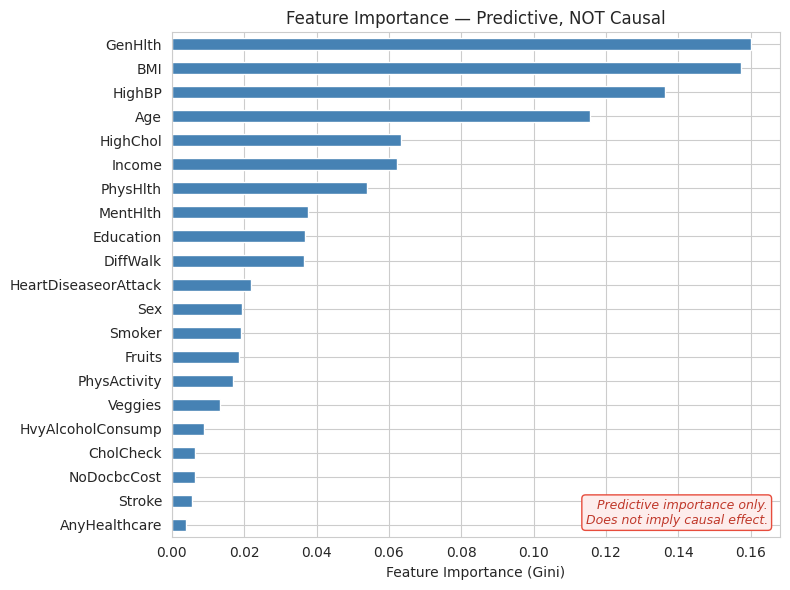

In [17]:
# ============================================================
# 4.1 Feature importance (Ch 19)
# ============================================================


importances = pd.Series(
     model_2.feature_importances_, index=X.columns
 ).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Feature Importance — Predictive, NOT Causal')

ax.text(
     0.98, 0.02,
     'Predictive importance only.\nDoes not imply causal effect.',
     transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
     style='italic', color='#c0392b',
     bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdedec', edgecolor='#e74c3c')
)

plt.tight_layout()
plt.show()

### 4.2 Key Visualization for Your Report

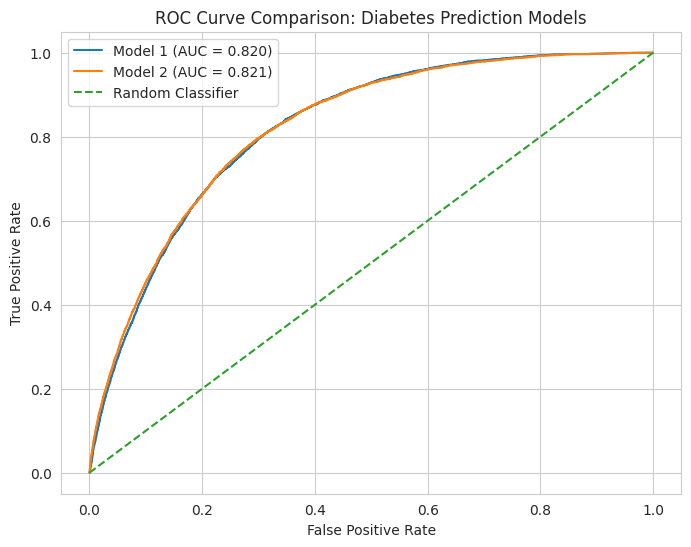

In [18]:
# ============================================================
# 4.2 Your key visualization
# ============================================================

from sklearn.metrics import roc_curve, roc_auc_score

y_prob_1 = model_1.predict_proba(X_test)[:, 1]
y_prob_2 = model_2.predict_proba(X_test)[:, 1]


fpr1, tpr1, _ = roc_curve(y_test, y_prob_1)
fpr2, tpr2, _ = roc_curve(y_test, y_prob_2)

auc1 = roc_auc_score(y_test, y_prob_1)
auc2 = roc_auc_score(y_test, y_prob_2)


plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label=f'Model 1 (AUC = {auc1:.3f})')
plt.plot(fpr2, tpr2, label=f'Model 2 (AUC = {auc2:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Diabetes Prediction Models')
plt.legend()
plt.show()

---
## Part 5: Recommendation

Use the SCR (Situation-Complication-Resolution) structure from Chapter 26.

**Situation:** ___
(What is the context? Who is the stakeholder? What decision do they face?)

A public health program or provider wants to identify which individuals are at elevated risk of diabetes so that they can help prompote initiatives in education and intervention. The decisions can be difficult since there can be so many factors that influence risk of diabetes.

**Complication:** ___
(What makes this decision hard? What uncertainty exists? What did your analysis reveal?)

The decision is difficult because from the data the target variable is very imbalanced, and there is no single feature that strongly correlates to diabetes on its own. The analysis shows the variables like general health, high bp, BMI, difficulty walking, and age are all associated with diabetes, but all play a small role, versus it being one variable.

**Resolution:** ___
(What do you recommend? Based on what evidence? With what confidence?)

I recommend using model 1 as the primary screening model as it showed a strong ability to distinguish between diabetes and non diabetes cases. This is based on the similar cross validated roc-auc and similar overall classification performance. Logistic regression provided nearly comparable predictive performance while offering greater interpretability, simpler deployment, and a much smaller model artifact. I am confident in model 1 because the cross validation results were stable across folds.

**Uncertainty Statement:** Based on our cross-validation results (metric = ___ +/- ___), we estimate that ___. The primary limitation is ___. We recommend ___ with the caveat that ___.

Based on our cross validation results (roc-auc = 0.8233 +/- 0.0024), we estimate that model 1 has a strong and stable predictive power in separating high risk from lower risk individuals. The primary limitation is this is a predictive model built on survey data, so it can and should only be used to predict risk rather than diagnose. We recommend model 1 with the caveat that predicted scores should promote follow up meetings with doctors and education.

In [19]:
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 98.9 MB/s eta 0:00:00


In [27]:
import joblib
joblib.dump(model_1, 'model.pkl')

['model.pkl']

In [28]:
print(X.columns.tolist())

['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


In [32]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import matplotlib.pyplot as plt


st.set_page_config(
    page_title="Diabetes Risk Prediction Dashboard",
    layout="wide"
)


MODEL_PATH = "model.pkl"

THRESHOLD = 0.50


model = joblib.load("model.pkl")


yes_no_map = {
    "No": 0,
    "Yes": 1
}

sex_map = {
    "Female": 0,
    "Male": 1
}

genhlth_map = {
    "Excellent": 1,
    "Very good": 2,
    "Good": 3,
    "Fair": 4,
    "Poor": 5
}

age_map = {
    "18–24": 1,
    "25–29": 2,
    "30–34": 3,
    "35–39": 4,
    "40–44": 5,
    "45–49": 6,
    "50–54": 7,
    "55–59": 8,
    "60–64": 9,
    "65–69": 10,
    "70–74": 11,
    "75–79": 12,
    "80 or older": 13
}

education_map = {
    "Never attended school or kindergarten only": 1,
    "Grades 1 through 8": 2,
    "Grades 9 through 11": 3,
    "Grade 12 or GED": 4,
    "College 1 to 3 years": 5,
    "College 4 years or more": 6
}

income_map = {
    "Less than $10,000": 1,
    "$10,000 to less than $15,000": 2,
    "$15,000 to less than $20,000": 3,
    "$20,000 to less than $25,000": 4,
    "$25,000 to less than $35,000": 5,
    "$35,000 to less than $50,000": 6,
    "$50,000 to less than $75,000": 7,
    "$75,000 or more": 8
}


st.title("Diabetes Risk Prediction Dashboard")
st.markdown(
    """
This dashboard estimates **diabetes risk** using health, demographic, and behavioral indicators.

It is intended as a **screening support tool**, not a medical diagnosis tool.
"""
)

st.info(
    "Important: This model provides a predictive risk estimate based on survey-style inputs. "
    "It should support awareness and follow-up decisions, not replace professional medical judgment."
)

st.sidebar.header("Enter Patient / User Information")

highbp_label = st.sidebar.selectbox(
    "High blood pressure",
    options=list(yes_no_map.keys()),
    help="Has the individual ever been told they have high blood pressure?"
)

highchol_label = st.sidebar.selectbox(
    "High cholesterol",
    options=list(yes_no_map.keys())
)

cholcheck_label = st.sidebar.selectbox(
    "Cholesterol check in the last 5 years",
    options=list(yes_no_map.keys())
)

bmi = st.sidebar.number_input(
    "Body Mass Index (BMI)",
    min_value=10.0,
    max_value=100.0,
    value=25.0,
    step=0.1
)

smoker_label = st.sidebar.selectbox(
    "Smoked at least 100 cigarettes in lifetime",
    options=list(yes_no_map.keys())
)

stroke_label = st.sidebar.selectbox(
    "History of stroke",
    options=list(yes_no_map.keys())
)

heart_label = st.sidebar.selectbox(
    "History of coronary heart disease or heart attack",
    options=list(yes_no_map.keys())
)

activity_label = st.sidebar.selectbox(
    "Physical activity in the past 30 days",
    options=list(yes_no_map.keys())
)

fruits_label = st.sidebar.selectbox(
    "Consumes fruit 1 or more times per day",
    options=list(yes_no_map.keys())
)

veggies_label = st.sidebar.selectbox(
    "Consumes vegetables 1 or more times per day",
    options=list(yes_no_map.keys())
)

alcohol_label = st.sidebar.selectbox(
    "Heavy alcohol consumption",
    options=list(yes_no_map.keys())
)

healthcare_label = st.sidebar.selectbox(
    "Any healthcare coverage",
    options=list(yes_no_map.keys())
)

nodoc_label = st.sidebar.selectbox(
    "Could not see doctor because of cost in past 12 months",
    options=list(yes_no_map.keys())
)

genhlth_label = st.sidebar.selectbox(
    "General health",
    options=list(genhlth_map.keys())
)

menthlth = st.sidebar.slider(
    "Days mental health was not good in past 30 days",
    min_value=0,
    max_value=30,
    value=0
)

physhlth = st.sidebar.slider(
    "Days physical health was not good in past 30 days",
    min_value=0,
    max_value=30,
    value=0
)

diffwalk_label = st.sidebar.selectbox(
    "Serious difficulty walking or climbing stairs",
    options=list(yes_no_map.keys())
)

sex_label = st.sidebar.selectbox(
    "Sex",
    options=list(sex_map.keys())
)

age_label = st.sidebar.selectbox(
    "Age group",
    options=list(age_map.keys())
)

education_label = st.sidebar.selectbox(
    "Education level",
    options=list(education_map.keys())
)

income_label = st.sidebar.selectbox(
    "Income level",
    options=list(income_map.keys())
)


input_df = pd.DataFrame([{
    "HighBP": yes_no_map[highbp_label],
    "HighChol": yes_no_map[highchol_label],
    "CholCheck": yes_no_map[cholcheck_label],
    "BMI": bmi,
    "Smoker": yes_no_map[smoker_label],
    "Stroke": yes_no_map[stroke_label],
    "HeartDiseaseorAttack": yes_no_map[heart_label],
    "PhysActivity": yes_no_map[activity_label],
    "Fruits": yes_no_map[fruits_label],
    "Veggies": yes_no_map[veggies_label],
    "HvyAlcoholConsump": yes_no_map[alcohol_label],
    "AnyHealthcare": yes_no_map[healthcare_label],
    "NoDocbcCost": yes_no_map[nodoc_label],
    "GenHlth": genhlth_map[genhlth_label],
    "MentHlth": menthlth,
    "PhysHlth": physhlth,
    "DiffWalk": yes_no_map[diffwalk_label],
    "Sex": sex_map[sex_label],
    "Age": age_map[age_label],
    "Education": education_map[education_label],
    "Income": income_map[income_label]
}])


probabilities = model.predict_proba(input_df)[0]
prob_no_diabetes = float(probabilities[0])
prob_diabetes = float(probabilities[1])

prediction = int(prob_diabetes >= THRESHOLD)
confidence = max(prob_no_diabetes, prob_diabetes)
distance_from_threshold = abs(prob_diabetes - THRESHOLD)


left_col, right_col = st.columns([1.1, 0.9])

with left_col:
    st.subheader("Prediction Output")

    st.metric(
        label="Predicted Probability of Diabetes",
        value=f"{prob_diabetes:.2%}"
    )

    st.metric(
        label="Predicted Probability of No Diabetes",
        value=f"{prob_no_diabetes:.2%}"
    )

    st.write(f"**Decision threshold:** {THRESHOLD:.2f}")

    if prediction == 1:
        st.error("Prediction: Higher diabetes risk")
    else:
        st.success("Prediction: Lower diabetes risk")

    st.subheader("Uncertainty")
    st.write(f"**Model confidence in predicted class:** {confidence:.2%}")

    if distance_from_threshold < 0.05:
        st.warning(
            "This prediction is close to the classification threshold, so it should be treated as less certain."
        )
    elif confidence >= 0.80:
        st.info("Confidence level: High")
    elif confidence >= 0.65:
        st.info("Confidence level: Moderate")
    else:
        st.info("Confidence level: Low")

    st.subheader("Interpretation")
    st.markdown(
        """
- A **higher diabetes risk** prediction means the input profile looks more similar to observations in the dataset classified as diabetes.
- A **lower diabetes risk** prediction means the input profile looks more similar to observations classified as non-diabetes.
- This is **predictive output**, not a diagnosis and not evidence of causation.
"""
    )

with right_col:
    st.subheader("Interactive Visualization")

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(
        ["No Diabetes", "Diabetes"],
        [prob_no_diabetes, prob_diabetes]
    )
    ax.set_ylim(0, 1)
    ax.set_ylabel("Predicted Probability")
    ax.set_title("Predicted Class Probabilities")
    st.pyplot(fig)


with st.expander("Show encoded model inputs"):
    st.dataframe(input_df)


st.markdown("---")
st.header("Input Definitions")

st.markdown(
    """
**High blood pressure / High cholesterol / Cholesterol check / Smoker / Stroke / Heart disease / Physical activity / Fruit intake / Vegetable intake / Heavy alcohol consumption / Healthcare coverage / Could not see doctor because of cost / Difficulty walking**
- These are all yes/no indicators.

**BMI**
- Body Mass Index, a standard weight-for-height measure.

**General health**
- Self-rated overall health: Excellent, Very good, Good, Fair, or Poor.

**Mental health**
- Number of days in the past 30 days when mental health was not good.

**Physical health**
- Number of days in the past 30 days when physical health was not good.

**Sex**
- Female or Male.

**Age group**
- Encoded age bracket used by the dataset.

**Education level**
- Highest level of education completed.

**Income level**
- Household income category used in the dataset.
"""
)

st.caption("Built using the CDC Diabetes Health Indicators dataset.")

Overwriting app.py


In [33]:
from google.colab import files
files.download("app.py")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:

from google.colab import files
files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
%%writefile requirements.txt
streamlit>=1.31.0
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.4.0
matplotlib>=3.7.0
seaborn>=0.12.0
joblib>=1.3.0


Writing requirements.txt


In [26]:
from google.colab import files
files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Part 6: Streamlit Export Guide

### 6.1 Creating app.py

Your Streamlit app should contain:
1. **Title and description** — `st.title()`, `st.markdown()`
2. **Input controls** — `st.slider()`, `st.selectbox()`, `st.number_input()`
3. **Model prediction** — load your trained model, generate predictions from user inputs
4. **Visualization** — at least one chart that updates with user inputs
5. **Uncertainty** — display confidence/prediction intervals alongside point estimates

### 6.2 Minimal app.py Template

```python
import streamlit as st
import pandas as pd
import numpy as np
import joblib  # to load saved model

st.title('Your Project Title')
st.markdown('Brief description of what this app predicts.')

# Sidebar controls
feature_1 = st.sidebar.slider('Feature 1', min_value=0.0, max_value=100.0, value=50.0)
feature_2 = st.sidebar.selectbox('Feature 2', ['Option A', 'Option B', 'Option C'])

# Load model (save with joblib.dump(model, 'model.pkl') in your notebook)
model = joblib.load('model.pkl')

# Predict
input_data = pd.DataFrame({'feature_1': [feature_1], 'feature_2': [feature_2]})
prediction = model.predict(input_data)[0]

st.metric('Prediction', f'{prediction:.2f}')
```

### 6.3 requirements.txt Template

```
streamlit>=1.31.0
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.4.0
matplotlib>=3.7.0
seaborn>=0.12.0
joblib>=1.3.0
```

### 6.4 Deployment Steps

1. Save your model: `joblib.dump(model_2, 'model.pkl')`
2. Test locally: `streamlit run app.py`
3. Push to GitHub: `app.py`, `model.pkl`, `requirements.txt`
4. Go to [streamlit.io/cloud](https://streamlit.io/cloud) and deploy
5. Submit the permanent URL on Canvas

---
## Part 7: AI Methodology Appendix

Document at least **3 AI interactions** using the P.R.I.M.E. framework. Copy and fill in the template below for each interaction.

---

### AI Interaction 1

**Prep:** What did you need? What context did you have before prompting?
> I needed help turning my trained moidel into a streamlit app after I had already trained and saved the model in my notebook. Before prompting, I had the saved model working in colab, but was confused how to get all of the separate files into github, aswell as making the app.py.

**Request:** What exact prompt did you write?
> I am writing an app based off of a trained model around the diabetes dataset, can you help me write an app.py file in colab based on the model?

**Iterate:** What did the AI return? What did you change or refine?
> At first AI returned an app that was not very user friendly, for example all of the inputs that the user would need to put in were either binary or in numbers that could confused the user. So I had it rewrite the code so it was easier to for users to input and understand what they are inputing.

**Mechanism Check:** How did you verify the output was correct?
> I checked on the app streamlit website to ensure that it was correct.

**Evaluate:** What human judgment did you apply? What did you accept/reject and why?
> The human judgment used was to make the app easily usable and more professional. AI assumed that every user would know about the dataset and understand each input, which is not realistic. I helped make it more user friendly, and had ai adjust the code, where I ultimately accepted it.

---

### AI Interaction 2

**Prep:** I needed help interpreting the exploratory data analysis. Before prompting, I had already generated plots showing target distribution and a correlation heatmap for the dataset. I could see taht the target was imbalanced and that there were multiple variables that were related to diabetes, not just one.

**Request:** I generated a correlation heatmap for my distribution plot for the diabetes dataset. Can you help me explain what these indciate and which features appear most correlated with the target.

**Iterate:** AI explained that the target variable was imbalanced and that variables such as general health, high bp, bmi, difficulty walking, high cholesterol, and age appeared to have the strongest associations with diabetes. It also pointed to some additional predictors such as general health, physical health, and difficulty walking, were all highly correlated with eachother.

**Mechanism Check:** I verified the interpretations from AI by comparing it directly with the correlation heatmap. I also made sure that the AI explanation was consistent with prediction vs causation.

**Evaluate:** I took the parts that helped me summarize the EDA findings and took out parts that sounded to definitive or causal. I used human judgment my confirming what AI gave me with the actual heatmap, to make sure everything was consistent.  

---

### AI Interaction 3

**Prep:** I needed help improving the model as the dataset is heavily imbalanced with much more non diabetic cases vs diabetic cases. Before prompting AI, I had trained the first version of the logistic regression model, but realized that the dataset was too imbalanced.

**Request:** My dataset is imbalanced, and my both of my models are only identifying a small share of the actual diabetes cases. Help me improve the model by handling class imbalance more appropriately and explain what changes I should make.

**Iterate:** AI suggested modifying the Logistic Regression model to account for class imbalance by using class_weight='balanced' and also recommended scaling the predictors through a pipeline. It explained that this would force the model to place more weight on the minority diabetes class and could improve recall.

**Mechanism Check:** I verified the AIs suggestion by rerunning the model with class_weight='balanced' and comparing the new classification report and ROC-AUC against the original version. I checked whether recall for the diabetes class improved and whether the new results made more sense for a screening use case.

**Evaluate:** Evaluate:
I accepted the recommendation to rebalance the Logistic Regression model because it directly addressed the models low recall for actual diabetes cases. I used my own judgment to compare the balanced models against the unbalanced models, and I made the final decision based on the actual metrics.
